In [1469]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [1470]:
path_port_serial = "/dev/ttyUSB1"

In [1471]:
#l = serial.Serial()
#l.port=path_port_serial
#l.baudrate = 115200
#l.bytesize = 8
#l.open()
#l.write(bytearray([2]))
#l.close()



In [1472]:
import random as rd
import time

In [1473]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [1474]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
  return [Ain,Bin]

In [1475]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [1476]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [1477]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [1478]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")


  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  s.open()

  #file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      print(X[j][i])
      time.sleep(2)
    #print('0b'+strbin,i)
    #print(int('0b'+strbin,2))
    #file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
    #  time.sleep(1/Fs)  
  s.write(bytearray([0]))
  s.write(bytearray([0]))
  s.write(bytearray([0]))
  s.close()  
  #file.close()
 

In [1479]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
print_matrix(M[1])


8 1 6 9 
2 9 1 1 
3 8 7 8 
7 5 6 4 


In [1480]:

#M1 = np.array([[5,7,8],[9,8,7],[1,5,5]])
#M2 = np.array([[7,5,10],[8,8,9],[1,9,6]])

In [1481]:
#M = [M1,M2]

In [1482]:
M[0].shape

(4, 4)

In [1483]:
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix(M_p[0],"IMPUT_A",1)
    send_matrix(M_p[1],"IMPUT_B",1)
    


---------------------- 0 --------------------------
0
0
0
4
0
0
5
1
0
1
7
2
7
8
8
3
4
8
3
0
7
4
0
0
2
0
0
0
0
0
0
9
0
0
6
1
0
1
1
8
8
9
7
4
2
8
6
0
3
5
0
0
7
0
0
0


M_p[0]@

In [1484]:
M[0]

array([[7, 4, 7, 2],
       [1, 8, 8, 4],
       [5, 7, 8, 3],
       [4, 1, 2, 3]])

In [1485]:
M[1]

array([[8, 1, 6, 9],
       [2, 9, 1, 1],
       [3, 8, 7, 8],
       [7, 5, 6, 4]])

In [1486]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

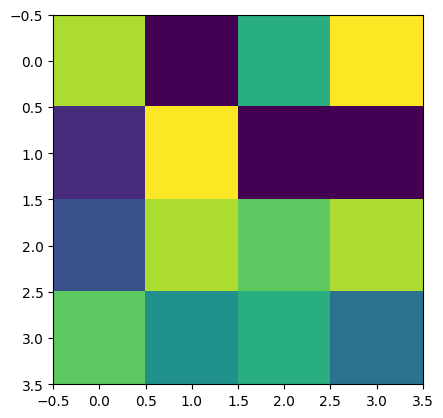

In [1487]:
plt.imshow(M[1])

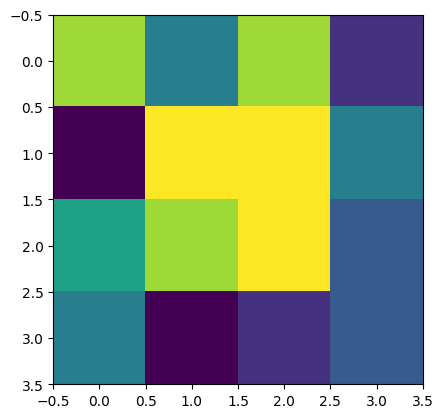

In [1488]:
plt.imshow(M[0])

In [1489]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [1490]:
M[1]@M[0]

array([[123,  91, 130,  65],
       [ 32,  88,  96,  46],
       [ 96, 133, 157,  83],
       [100, 114, 145,  64]])

In [1491]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

In [1492]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 7, 4, 7, 2],
        [0, 0, 1, 8, 8, 4, 0],
        [0, 5, 7, 8, 3, 0, 0],
        [4, 1, 2, 3, 0, 0, 0]]),
 array([[0, 0, 0, 7, 1, 5, 4],
        [0, 0, 4, 8, 7, 1, 0],
        [0, 7, 8, 8, 2, 0, 0],
        [2, 4, 3, 3, 0, 0, 0]]))

In [1493]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [1494]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

In [1495]:
M

[array([[7, 4, 7, 2],
        [1, 8, 8, 4],
        [5, 7, 8, 3],
        [4, 1, 2, 3]]),
 array([[8, 1, 6, 9],
        [2, 9, 1, 1],
        [3, 8, 7, 8],
        [7, 5, 6, 4]])]

In [1496]:
M_p[0]

array([[0, 0, 0, 7, 4, 7, 2],
       [0, 0, 1, 8, 8, 4, 0],
       [0, 5, 7, 8, 3, 0, 0],
       [4, 1, 2, 3, 0, 0, 0]])

In [1497]:
M_p[1]

array([[0, 0, 0, 7, 1, 5, 4],
       [0, 0, 4, 8, 7, 1, 0],
       [0, 7, 8, 8, 2, 0, 0],
       [2, 4, 3, 3, 0, 0, 0]])

In [1498]:
def send_matrix(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [1499]:
len(str("0000000000000009"))*4


64

In [1500]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

In [1501]:
M_p[1]

array([[0, 0, 0, 8, 2, 3, 7],
       [0, 0, 1, 9, 8, 5, 0],
       [0, 6, 1, 7, 6, 0, 0],
       [9, 1, 8, 4, 0, 0, 0]])

In [1502]:
M_p[0]

array([[0, 0, 0, 7, 4, 7, 2],
       [0, 0, 1, 8, 8, 4, 0],
       [0, 5, 7, 8, 3, 0, 0],
       [4, 1, 2, 3, 0, 0, 0]])

In [1503]:
print_matrix(M[0]@M[1])

99 109 107 131 
76 157 94 97 
99 147 111 128 
61 44 57 65 


In [1504]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

In [1505]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 7, 4, 7, 2],
        [0, 0, 1, 8, 8, 4, 0],
        [0, 5, 7, 8, 3, 0, 0],
        [4, 1, 2, 3, 0, 0, 0]]),
 array([[0, 0, 0, 8, 2, 3, 7],
        [0, 0, 1, 9, 8, 5, 0],
        [0, 6, 1, 7, 6, 0, 0],
        [9, 1, 8, 4, 0, 0, 0]])]

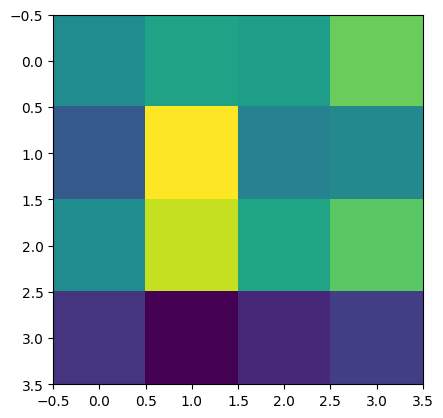

In [1506]:
plt.imshow(M[0]@M[1])

plt.show()

In [1507]:

for i in range(100):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [1508]:
M[0]

array([[7, 4, 7, 2],
       [1, 8, 8, 4],
       [5, 7, 8, 3],
       [4, 1, 2, 3]])

In [1509]:
M[1]

array([[8, 1, 6, 9],
       [2, 9, 1, 1],
       [3, 8, 7, 8],
       [7, 5, 6, 4]])

In [1510]:
M[0]@M[1]

array([[ 99, 109, 107, 131],
       [ 76, 157,  94,  97],
       [ 99, 147, 111, 128],
       [ 61,  44,  57,  65]])

In [1511]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [1512]:
i =1
s.write(bytearray([int(i)]))


1

In [1513]:
serial.Serial()

Serial<id=0x7f2fd03c69b0, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)